# Graph Database Management Systems (Neo4J) 

In this lab, we will

   1. Get familiar with Neo4J NoSQL Graph Database Management System.
   3. Convert a RDBMS Schema to a Graph Schema.
   2. Perform some queries on the Graph database using Cypher Query Language.

## Neo4J:
   <a href="https://neo4j.com/">Neo4J</a>  is a graph database management system developed by Neo4j, Inc. Described by its developers as a native graph storage and processing. It is the most popular graph database according to DB-Engines ranking, and the 22nd most popular database overall.
<img src="https://neo4j.com/wp-content/themes/neo4jweb/assets/images/neo4j-logo-2015.png">

## Installation
 1. Download the Neo4J <b>Community Server</b> from <a href="https://neo4j.com/download-center/#releases">here</a>. Follow the installation guide provided after the download for each operating system. <b>To start the Neo4J server run the following command in the terminal:</b>
```
neo4j/bin/neo4j start
```

2. Install The Neo4j Python driver which is officially supported by Neo4j and connects to the database using the binary protocol. It aims to be minimal, while being idiomatic to Python. <a href="https://neo4j.com/developer/python/">here</a>:
```
pip install neo4j
```

In [0]:
# !pip install neo4j

In [0]:
import pandas as pd
import numpy as np

# import the neo4j driver for Python
from neo4j import GraphDatabase

## Converting a RDB to a Graph DB

You can watch the following [video](https://www.youtube.com/embed/NO3C-CWykkY) mentions some of the advantages of Graph Database model over the Relational DB model.

Here are some of the key advantages of Using Neo4J over RDBMS:

1. It's easier to spot the relationships between the attributes.

2. No need for thinking how and what entities to join to make a query.

3. It's flexible to schema changes.

**First, we need to start the Neo4J server locally**

<b>To start the Neo4J server run the following command in the terminal and open neo4j server at http://localhost:7474/ to enter the login credentials.</b>
``` 
neo4j/bin/neo4j console
Default Username: neo4j
Default Password: neo4j
```

**We will use Cypher Query Language to create the above Graph toy database**

In [0]:
# Database Credentials
uri = "bolt://localhost:7687" 

userName = "neo4j" 
password = "test" 

# Connect to the neo4j database server
graphDB_Driver = GraphDatabase.driver(uri, auth=(userName, password),
                                      encrypted=False)

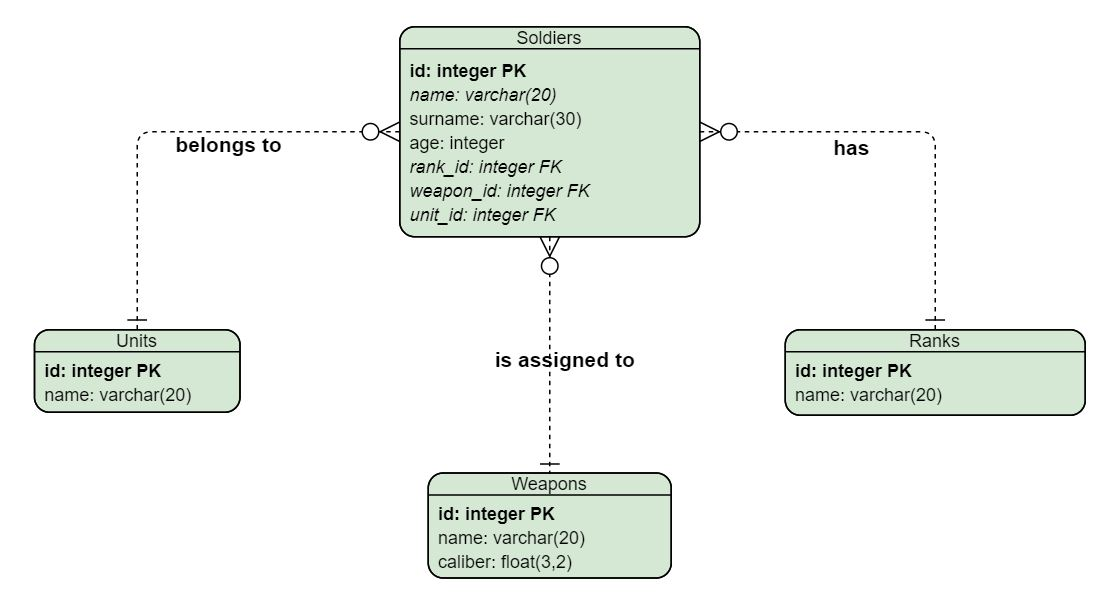

In [1]:
from IPython.display import Image
Image("ER.jpeg")

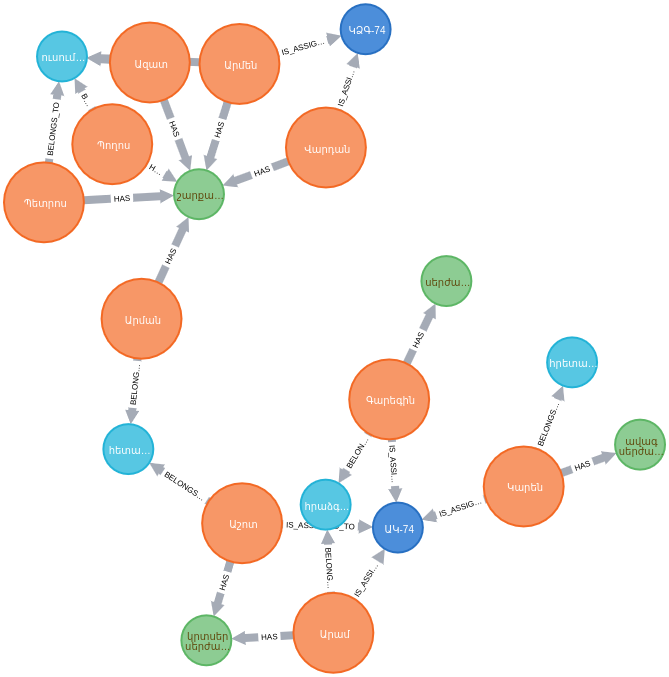

In [2]:
Image("graph.png")

In [0]:
cql_ranks = """
LOAD CSV WITH HEADERS FROM "File:///ranks.txt" AS row
FIELDTERMINATOR '\t'
CREATE (n:Rank)
SET n = row,
n.id = toInteger(row.id)
"""

cql_units = """
LOAD CSV WITH HEADERS FROM "File:///units.txt" AS row
FIELDTERMINATOR '\t'
CREATE (n:Unit)
SET n = row,
n.id = toInteger(row.id)
"""

cql_weapons = """
LOAD CSV WITH HEADERS FROM "File:///weapons.txt" AS row
FIELDTERMINATOR '\t'
CREATE (n:Weapon)
SET n = row,
n.id = toInteger(row.id),
n.caliber = toFloat(row.caliber)
"""

cql_soldiers = """
LOAD CSV WITH HEADERS FROM "File:///soldiers.txt" AS row
FIELDTERMINATOR '\t'
CREATE (n:Soldier)
SET n = row,
n.id = toInteger(row.id),
n.age = toInteger(row.age),
n.rank_id = toInteger(row.rank_id),
n.weapon_id = toInteger(row.weapon_id),
n.unit_id = toInteger(row.unit_id)
"""

with graphDB_Driver.session() as graphDB_Session:
    graphDB_Session.run(cql_ranks)
    graphDB_Session.run(cql_units)
    graphDB_Session.run(cql_weapons)
    graphDB_Session.run(cql_soldiers)

**Assigning the indices**

In [0]:
cql_indices_rank = "CREATE INDEX FOR (r:Rank) ON (r.id)"
cql_indices_unit = "CREATE INDEX FOR (u:Unit) ON (u.id)"
cql_indices_weapon = "CREATE INDEX FOR (w:Weapon) ON (w.id)"

with graphDB_Driver.session() as graphDB_Session:
    graphDB_Session.run(cql_indices_rank)
    graphDB_Session.run(cql_indices_unit)
    graphDB_Session.run(cql_indices_weapon)

**Creating data relationships**

In [0]:
cql_rel_rank = """
MATCH (s:Soldier),(r:Rank)
WHERE s.rank_id = r.id
CREATE (s)-[:HAS]->(r)
"""

cql_rel_unit = """
MATCH (s:Soldier),(u:Unit)
WHERE s.unit_id = u.id
CREATE (s)-[:BELONGS_TO]->(u)
"""
cql_rel_weapon = """
MATCH (s:Soldier),(w:Weapon)
WHERE s.weapon_id = w.id
CREATE (s)-[:IS_ASSIGNED_TO]->(w)
"""

with graphDB_Driver.session() as graphDB_Session:
    graphDB_Session.run(cql_rel_rank)
    graphDB_Session.run(cql_rel_unit)
    graphDB_Session.run(cql_rel_weapon)

**select all soldier nodes in the graph**

In [0]:
cql_node_query = "MATCH (s:Soldier) RETURN s.name, s.surname"

with graphDB_Driver.session() as graphDB_Session:
    nodes = graphDB_Session.run(cql_node_query)

    for node in nodes:
        print(f'{node["s.name"]} {node["s.surname"]}')

Արմեն Աբրահամյան
Պողոս Սարգսյան
Պետրոս Պողոսյան
Ազատ Մալխասյան
Աշոտ Ազատյան
Արամ Աշոտյան
Գարեգին Արամյան
Կարեն Մելքոնյան
Արման Վարդանյան
Վարդան Հակոբյան


In [0]:
connection = graphDB_Driver.session()
result = connection.run("MATCH (a)-[:HAS]->(b) RETURN a.name AS name, b.rank AS rank")
for record in result:
    print("{}ը ունի {}ի զինվորական կոչում ".format(record["name"], record["rank"]))

Արմենը ունի շարքայինի զինվորական կոչում 
Պողոսը ունի շարքայինի զինվորական կոչում 
Պետրոսը ունի շարքայինի զինվորական կոչում 
Ազատը ունի շարքայինի զինվորական կոչում 
Աշոտը ունի կրտսեր սերժանտի զինվորական կոչում 
Արամը ունի կրտսեր սերժանտի զինվորական կոչում 
Գարեգինը ունի սերժանտի զինվորական կոչում 
Կարենը ունի ավագ սերժանտի զինվորական կոչում 
Արմանը ունի շարքայինի զինվորական կոչում 
Վարդանը ունի շարքայինի զինվորական կոչում 


We can also write a helper function to store the data in a pandas `DataFrame`.

In [0]:
def query_to_dataframe(node_info):
    out = None
    for node in node_info:
        if out is not None:
            out = pd.concat([out, pd.DataFrame([dict(node)])], axis=0)
        else:
            out = pd.DataFrame([dict(node)])
    out.index = np.arange(out.shape[0])
    return out

In [0]:
cqlEdgeQuery = """
MATCH (u:Unit)<-[:BELONGS_TO]-(s:Soldier)
RETURN s.name, s.surname, u.name
"""
nodes = connection.run(cqlEdgeQuery)
df = query_to_dataframe(nodes)
df

,s.name,s.surname,u.name
0,Կարեն,Մելքոնյան,հրետանային դիվիզիոն
1,Արման,Վարդանյան,հետախուզական վաշտ
2,Աշոտ,Ազատյան,հետախուզական վաշտ
3,Պետրոս,Պողոսյան,ուսումնական գումարտակ
4,Պողոս,Սարգսյան,ուսումնական գումարտակ
5,Ազատ,Մալխասյան,ուսումնական գումարտակ
6,Արմեն,Աբրահամյան,ուսումնական գումարտակ
7,Արամ,Աշոտյան,հրաձգային գումարտակ
8,Գարեգին,Արամյան,հրաձգային գումարտակ


In [0]:
cqlEdgeQuery = """
MATCH (u:Unit)<-[:BELONGS_TO]-(s:Soldier)-[:IS_ASSIGNED_TO]->(w:Weapon),
(s:Soldier)-[:HAS]->(r:Rank)
RETURN s.name, s.surname, u.name, w.name, r.rank
"""
nodes = connection.run(cqlEdgeQuery)
df = query_to_dataframe(nodes)
df

,r.rank,s.name,s.surname,u.name,w.name
0,ավագ սերժանտ,Կարեն,Մելքոնյան,հրետանային դիվիզիոն,ԱԿ-74
1,շարքային,Արման,Վարդանյան,հետախուզական վաշտ,ԿԳ
2,կրտսեր սերժանտ,Աշոտ,Ազատյան,հետախուզական վաշտ,ԱԿ-74
3,շարքային,Պետրոս,Պողոսյան,ուսումնական գումարտակ,ԿԳ
4,շարքային,Պողոս,Սարգսյան,ուսումնական գումարտակ,ՁՀՆ-7
5,շարքային,Ազատ,Մալխասյան,ուսումնական գումարտակ,ՍՎԴ
6,շարքային,Արմեն,Աբրահամյան,ուսումնական գումարտակ,ԿՁԳ-74
7,կրտսեր սերժանտ,Արամ,Աշոտյան,հրաձգային գումարտակ,ԱԿ-74
8,սերժանտ,Գարեգին,Արամյան,հրաձգային գումարտակ,ԱԿ-74


## Movie Graph

We will create the database with a single Cypher query statement composed of multiple CREATE clauses. This will create the movie graph.

In [0]:
with open('movie-graph.txt') as f:
    query = f.read()

In [0]:
with graphDB_Driver.session() as graphDB_Session:
    graphDB_Session.run(query)

In [0]:
def run_query(query, connection):
    return query_to_dataframe(connection.run(query))

**Find some actors.**

In [0]:
q = 'MATCH (people:Person) RETURN people.name LIMIT 10'

In [0]:
connection = graphDB_Driver.session()
run_query(q, connection)

,people.name
0,Keanu Reeves
1,Carrie-Anne Moss
2,Laurence Fishburne
3,Hugo Weaving
4,Lilly Wachowski
5,Lana Wachowski
6,Joel Silver
7,Emil Eifrem
8,Charlize Theron
9,Al Pacino


**Find movies released in the 90s.**

In [0]:
q = """
MATCH (h:Movie) 
WHERE h.released >= 1990 
AND
h.released < 2000
RETURN h.title
"""
run_query(q, connection)

,h.title
0,The Matrix
1,The Devil's Advocate
2,A Few Good Men
3,As Good as It Gets
4,What Dreams May Come
5,Snow Falling on Cedars
6,You've Got Mail
7,Sleepless in Seattle
8,Joe Versus the Volcano
9,When Harry Met Sally


**List all Tom Hanks movies**

In [0]:
q = """
MATCH (tom:Person {name: "Tom Hanks"})-[:ACTED_IN]->(tomHanksMovies) 
RETURN tomHanksMovies.title AS title,
tomHanksMovies.tagline AS tagline,
tomHanksMovies.released AS released
"""

# equivalently
# q = """
# MATCH (tom)-[:ACTED_IN]->(tomHanksMovies) 
# Where tom.name = "Tom Hanks"
# RETURN tomHanksMovies.title AS title,
# tomHanksMovies.tagline AS tagline,
# tomHanksMovies.released AS released
# """

run_query(q, connection)

,released,tagline,title
0,1996,In every life there comes a time when that thi...,That Thing You Do
1,1992,Once in a lifetime you get a chance to do some...,A League of Their Own
2,2012,Everything is connected,Cloud Atlas
3,2007,A stiff drink. A little mascara. A lot of nerv...,Charlie Wilson's War
4,1995,"Houston, we have a problem.",Apollo 13
5,1993,"What if someone you never met, someone you nev...",Sleepless in Seattle
6,2006,Break The Codes,The Da Vinci Code
7,1998,At odds in life... in love on-line.,You've Got Mail
8,1999,Walk a mile you'll never forget.,The Green Mile
9,2000,"At the edge of the world, his journey begins.",Cast Away


In [0]:
q = """
MATCH (tom:Person {name:"Tom Hanks"})-[:ACTED_IN]->(m)<-[:ACTED_IN]-(coActors) 
RETURN DISTINCT coActors.name
"""
run_query(q, connection)

,coActors.name
0,Liv Tyler
1,Charlize Theron
2,Rosie O'Donnell
3,Bill Paxton
4,Madonna
5,Geena Davis
6,Lori Petty
7,Jim Broadbent
8,Hugo Weaving
9,Halle Berry


Let's recommend new co-actors for Tom Hanks. A basic recommendation approach is to find connections past an immediate neighborhood which are themselves well connected.

For Tom Hanks, that means:

1. Find actors that Tom Hanks hasn't yet worked with, but his co-actors have.

2. Find someone who can introduce Tom to his potential co-actor.

Extend Tom Hanks co-actors, to find co-co-actors who haven't worked with Tom Hanks.

In [0]:
q1 = """
MATCH (tom:Person {name:"Tom Hanks"})-[:ACTED_IN]->(m)<-[:ACTED_IN]-(coActors),
  (coActors)-[:ACTED_IN]->(m2)<-[:ACTED_IN]-(cocoActors)
WHERE NOT (tom)-[:ACTED_IN]->()<-[:ACTED_IN]-(cocoActors) AND tom <> cocoActors    
RETURN cocoActors.name AS Recommended, COUNT(*) AS Strength 
ORDER BY Strength DESC
"""

run_query(q1, connection)

,Recommended,Strength
0,Zach Grenier,5
1,Tom Cruise,5
2,Keanu Reeves,4
3,Cuba Gooding Jr.,4
4,Laurence Fishburne,3
5,Carrie-Anne Moss,3
6,Jack Nicholson,3
7,Carrie Fisher,3
8,Billy Crystal,3
9,Bruno Kirby,3


**Find someone to introduce Tom Hanks to Tom Cruise.**

In [0]:
q2 = """
MATCH (tom:Person {name:"Tom Hanks"})-[:ACTED_IN]->(m)<-[:ACTED_IN]-(coActors),
  (coActors)-[:ACTED_IN]->(m2)<-[:ACTED_IN]-(cruise:Person {name:"Tom Cruise"})
RETURN coActors.name
"""
run_query(q2, connection)

,coActors.name
0,Kevin Bacon
1,Meg Ryan
2,Meg Ryan
3,Bonnie Hunt
4,Meg Ryan


**Get the youndest age of movie producers in ascending order**

In [0]:
q = """
MATCH (p: Person)-[:PRODUCED]->(m)
RETURN p.name, MIN(m.released - p.born) AS age
ORDER BY age ASC
"""
run_query(q, connection)

,age,p.name
0,39,Lilly Wachowski
1,41,Lana Wachowski
2,43,Cameron Crowe
3,47,Joel Silver
4,51,Rob Reiner
5,51,Stefan Arndt
6,54,Nancy Meyers
7,57,Nora Ephron


**Get the average age of the actors who played in the given movie.**

In [0]:
q = """
MATCH (p: Person)-[:ACTED_IN]->(m)
RETURN m.title AS movie_title, AVG(m.released-p.born) AS avg_age
ORDER BY avg_age ASC
"""
run_query(q, connection)

,avg_age,movie_title
0,20.142857,Stand By Me
1,26.666667,That Thing You Do
2,29.666667,Jerry Maguire
3,30.333333,Top Gun
4,32.333333,Joe Versus the Volcano
5,33.000000,The Matrix
6,33.333333,You've Got Mail
7,33.666667,A Few Good Men
8,34.333333,A League of Their Own
9,34.500000,One Flew Over the Cuckoo's Nest


**Get the total number of actors who played in the given movie.**

In [0]:
q = """
MATCH (p: Person)-[:ACTED_IN]->(m)
RETURN m.title AS movie_title, COUNT(p) AS number_of_actors
ORDER BY number_of_actors DESC
"""
run_query(q, connection)

,movie_title,number_of_actors
0,A Few Good Men,12
1,Jerry Maguire,9
2,The Green Mile,8
3,Stand By Me,7
4,Speed Racer,7
5,Top Gun,6
6,You've Got Mail,6
7,Sleepless in Seattle,6
8,A League of Their Own,6
9,The Matrix,5


**Sort the movies in terms of their tagline lenght**

In [0]:
q = """
MATCH (m:Movie)
RETURN m.title AS movie_title, SIZE(m.tagline) AS line, m.tagline
ORDER BY line ASC
"""
run_query(q, connection)

,line,m.tagline,movie_title
0,14,Free your mind,The Matrix Reloaded
1,15,Come as you are,The Birdcage
2,15,Break The Codes,The Da Vinci Code
3,17,Freedom! Forever!,V for Vendetta
4,19,Speed has no limits,Speed Racer
5,23,Everything is connected,Cloud Atlas
6,25,Welcome to the Real World,The Matrix
7,25,Evil has its winning ways,The Devil's Advocate
8,26,First loves last. Forever.,Snow Falling on Cedars
9,27,"Houston, we have a problem.",Apollo 13


**Get the movies whose taglines contain the word `love`**

In [0]:
q = """
MATCH (m:Movie)
WHERE m.tagline CONTAINS "love"
RETURN m.title AS movie_title,  m.tagline
"""
run_query(q, connection)

,m.tagline,movie_title
0,First loves last. Forever.,Snow Falling on Cedars
1,At odds in life... in love on-line.,You've Got Mail
2,"A story of love, lava and burning desire.",Joe Versus the Volcano
3,Can two friends sleep together and still love ...,When Harry Met Sally


**Taglines that start with the phrase `The`**

In [0]:
q = """
MATCH (m:Movie)
WHERE m.tagline STARTS WITH "The"
RETURN m.title AS movie_title,  m.tagline
"""
run_query(q, connection)

,m.tagline,movie_title
0,"In the heart of the nation's capital, in a cou...",A Few Good Men
1,"I feel the need, the need for speed.",Top Gun
2,The rest of his life begins now.,Jerry Maguire
3,"For some, it's the last real taste of innocenc...",Stand By Me
4,A comedy from the heart that goes for the throat.,As Good as It Gets
5,After life there is more. The end is just the ...,What Dreams May Come
6,First loves last. Forever.,Snow Falling on Cedars
7,At odds in life... in love on-line.,You've Got Mail
8,"A story of love, lava and burning desire.",Joe Versus the Volcano
9,Walk a mile you'll never forget.,The Green Mile


**What is the age of the youngest actor in the movie where the most actors took part in**

In [0]:
q = """
MATCH (p)-[:ACTED_IN]->(m:Movie)
RETURN m.title AS movie_title,  COUNT(p) AS actors, MIN(m.released-p.born) AS smallest_age
ORDER BY actors DESC
LIMIT 1
"""
run_query(q, connection)

,actors,movie_title,smallest_age
0,12,A Few Good Men,21


**Sort the actors in terms of the number of movies they took part in**

In [0]:
q = """
MATCH (p)-[:ACTED_IN]->(m:Movie)
RETURN p.name, COUNT(m) AS number_of_movies
ORDER BY number_of_movies DESC
"""
run_query(q, connection)

,number_of_movies,p.name
0,12,Tom Hanks
1,7,Keanu Reeves
2,5,Hugo Weaving
3,5,Jack Nicholson
4,5,Meg Ryan
5,4,Cuba Gooding Jr.
6,3,Laurence Fishburne
7,3,Carrie-Anne Moss
8,3,Kevin Bacon
9,3,Tom Cruise


**Sort people in terms of their relation with each movie**

In [0]:
q = """
MATCH (p:Person)-[r]->(m:Movie)
RETURN m.title, p.name, COUNT(r) AS number_of_relations
ORDER BY number_of_relations DESC
"""
run_query(q, connection)

,m.title,number_of_relations,p.name
0,Jerry Maguire,3,Cameron Crowe
1,Something's Gotta Give,3,Nancy Meyers
2,A Few Good Men,2,Aaron Sorkin
3,When Harry Met Sally,2,Nora Ephron
4,When Harry Met Sally,2,Rob Reiner
5,That Thing You Do,2,Tom Hanks
6,Unforgiven,2,Clint Eastwood
7,V for Vendetta,2,Lana Wachowski
8,V for Vendetta,2,Lilly Wachowski
9,Speed Racer,2,Lilly Wachowski


**List of directors and their movies**

In [0]:
q = """
MATCH (p:Person)-[:DIRECTED]->(m:Movie)
RETURN p.name, m.title
"""
run_query(q, connection)

,m.title,p.name
0,The Matrix,Lilly Wachowski
1,The Matrix,Lana Wachowski
2,The Matrix Reloaded,Lilly Wachowski
3,The Matrix Reloaded,Lana Wachowski
4,The Matrix Revolutions,Lana Wachowski
5,The Matrix Revolutions,Lilly Wachowski
6,The Devil's Advocate,Taylor Hackford
7,A Few Good Men,Rob Reiner
8,Top Gun,Tony Scott
9,Jerry Maguire,Cameron Crowe


**We can also insert data from the web into our database using this kind of script.** 

```
LOAD CSV WITH HEADERS FROM "http://data.neo4j.com/northwind/order-details.csv" AS row
MATCH (p:Product), (o:Order)
WHERE p.productID = row.productID AND o.orderID = row.orderID
CREATE (o)-[details:ORDERS]->(p)
SET details = row,
details.quantity = toInteger(row.quantity)
```